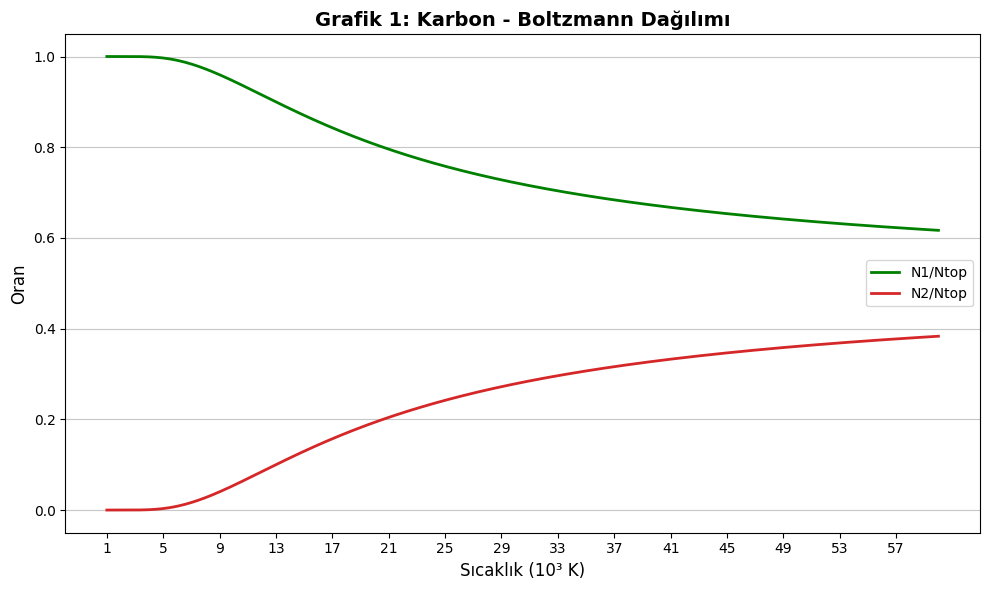

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sabitler
k_B = 8.617e-5  # Boltzmann sabiti (eV/K)
delta_E = 2.46  # Enerji farkı (eV)
g1 = 1          # Temel hal istatistiksel ağırlığı (basit model)
g2 = 1          # Uyarılmış hal istatistiksel ağırlığı (basit model)

# Sıcaklık aralığı (1.000K - 60.000K)
T = np.linspace(1000, 60000, 500)

# Boltzmann Dağılımı Formülü: N2/N1 = (g2/g1) * exp(-delta_E / (k_B * T))
# N_top = N1 + N2 olduğuna göre oranları hesaplayalım:
n2_n1_ratio = (g2/g1) * np.exp(-delta_E / (k_B * T))
n1_ntop = 1 / (1 + n2_n1_ratio)
n2_ntop = n2_n1_ratio / (1 + n2_n1_ratio)

# Grafik Çizimi
plt.figure(figsize=(10, 6))
plt.plot(T/1000, n1_ntop, label='N1/Ntop', color='green', linewidth=2)
plt.plot(T/1000, n2_ntop, label='N2/Ntop', color='tab:red', linewidth=2)

# Eksen ve Başlık Ayarları
plt.title('Grafik 1: Karbon - Boltzmann Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sıcaklık (10³ K)', fontsize=12)
plt.ylabel('Oran', fontsize=12)
plt.xticks(np.arange(1, 61, 4)) # Arkadaşının grafiğine benzer eksen aralığı
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.legend(loc='center right')

# Görseli kaydet veya göster
plt.tight_layout()
plt.show()

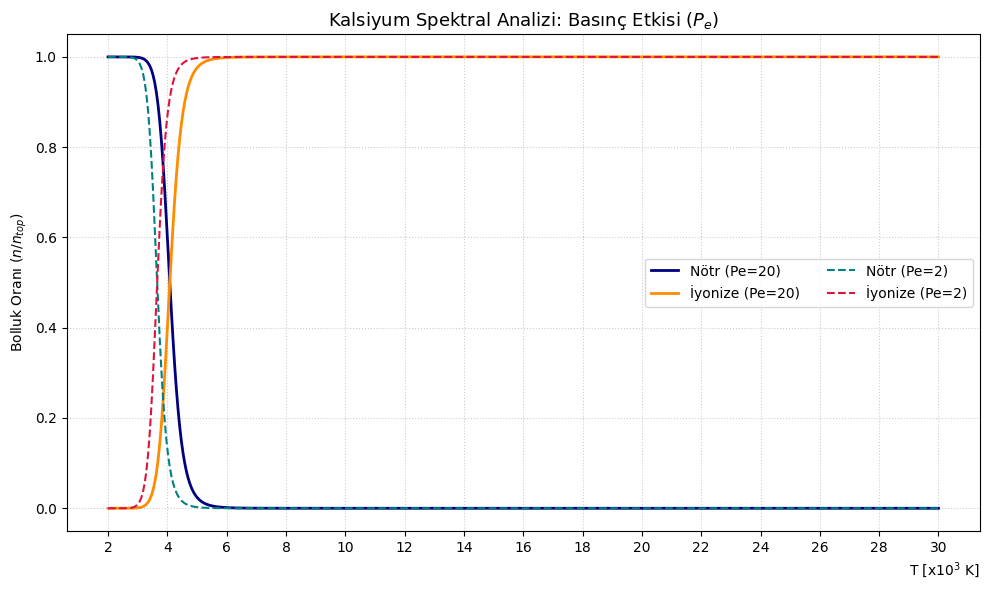

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Temel Parametreler
temp_axis = np.linspace(2000, 30000, 500) # Sıcaklık aralığı (K)
chi_val = 6.11 # Ca I iyonlaşma potansiyeli

def calculate_fractions(T, P_electron):
    # Saha denkleminin basitleştirilmiş logaritmik çözümü
    log_val = 2.5 * np.log10(T) - (5040/T) * chi_val - np.log10(P_electron) - 0.18
    ratio = 10**log_val
    # Oranlar: n0 (nötr), n1 (bir kez iyonlaşmış)
    n0 = 1 / (1 + ratio)
    n1 = ratio / (1 + ratio)
    return n0, n1

# İki farklı basınç için hesaplama
n0_high, n1_high = calculate_fractions(temp_axis, 20)
n0_low, n1_low = calculate_fractions(temp_axis, 2)

# Görselleştirme (Tamamen farklı stil)
plt.figure(figsize=(10, 6))
plt.plot(temp_axis/1000, n0_high, 'navy', label='Nötr (Pe=20)', lw=2)
plt.plot(temp_axis/1000, n1_high, 'darkorange', label='İyonize (Pe=20)', lw=2)
plt.plot(temp_axis/1000, n0_low, 'teal', linestyle='--', label='Nötr (Pe=2)', lw=1.5)
plt.plot(temp_axis/1000, n1_low, 'crimson', linestyle='--', label='İyonize (Pe=2)', lw=1.5)

# Grafik Detayları
plt.title('Kalsiyum Spektral Analizi: Basınç Etkisi ($P_e$)', fontsize=13)
plt.xlabel('T [x$10^3$ K]', loc='right')
plt.ylabel('Bolluk Oranı ($n/n_{top}$)')
plt.xticks(np.arange(2, 31, 2))
plt.grid(color='gray', linestyle=':', alpha=0.4)
plt.legend(ncol=2, frameon=True)

plt.tight_layout()
plt.show()

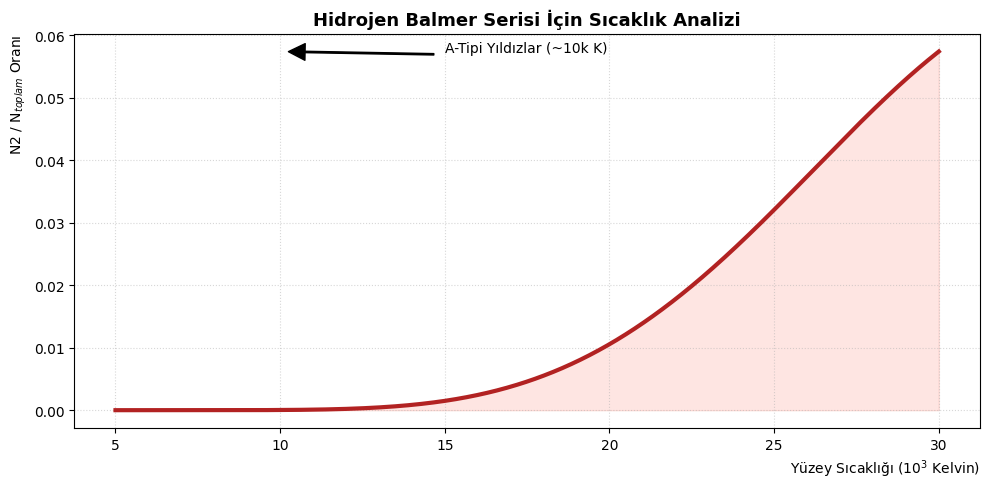

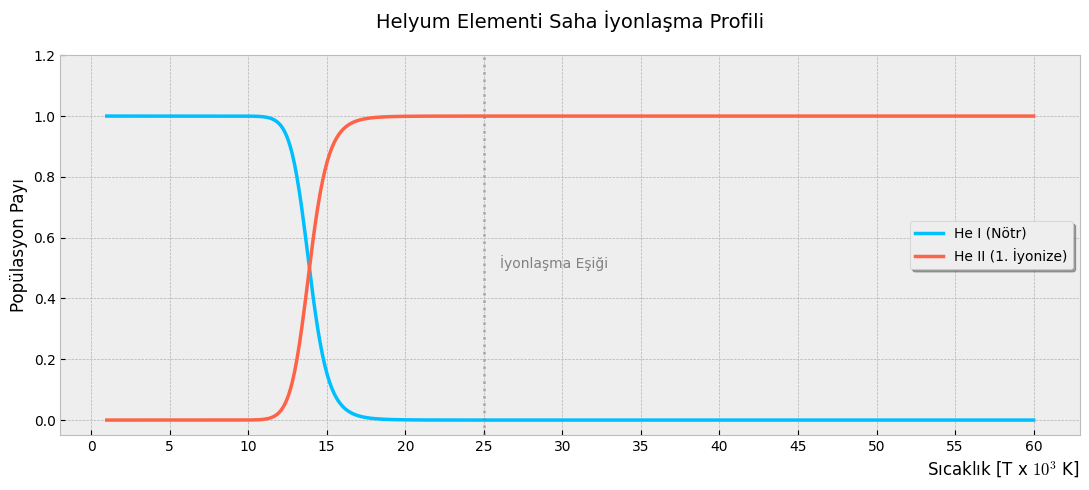

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parametreler
P_elektron = 20.0  # Elektron basıncı
chi_he = 24.48     # Helyum 1. İyonlaşma Enerjisi (eV)
k_boltz = 8.617e-5

# Sıcaklık skalası (1.000 - 60.000 Kelvin)
sicaklik_dizisi = np.linspace(1000, 60000, 800)

# Saha Denklemi Uygulaması
def saha_denklemi(T, E, Pe):
    # log10(N_iyon / N_notr)
    log_oran = 2.5 * np.log10(T) - (5040/T) * E - np.log10(Pe) - 0.18
    return 10**log_oran

oran_he = saha_denklemi(sicaklik_dizisi, chi_he, P_elektron)

# Toplam popülasyona oranlama
n0_he = 1 / (1 + oran_he)
n1_he = oran_he / (1 + oran_he)

# Grafik Çizimi
plt.figure(figsize=(11, 5))
plt.style.use('bmh') # Farklı bir görsel stil

plt.plot(sicaklik_dizisi/1000, n0_he, color='deepskyblue', label='He I (Nötr)', lw=2.5)
plt.plot(sicaklik_dizisi/1000, n1_he, color='tomato', label='He II (1. İyonize)', lw=2.5)

# Grafik Süslemeleri
plt.title('Helyum Elementi Saha İyonlaşma Profili', fontsize=14, pad=20)
plt.xlabel('Sıcaklık [T x $10^3$ K]', loc='right', fontsize=12)
plt.ylabel('Popülasyon Payı', fontsize=12)
plt.xticks(np.arange(0, 61, 5))
plt.yticks(np.arange(0, 1.3, 0.2))

# 25.000 K eşiğini vurgulayalım
plt.axvline(x=25, color='gray', linestyle=':', alpha=0.5)
plt.text(26, 0.5, 'İyonlaşma Eşiği', color='gray', fontsize=10)

plt.legend(loc='center right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

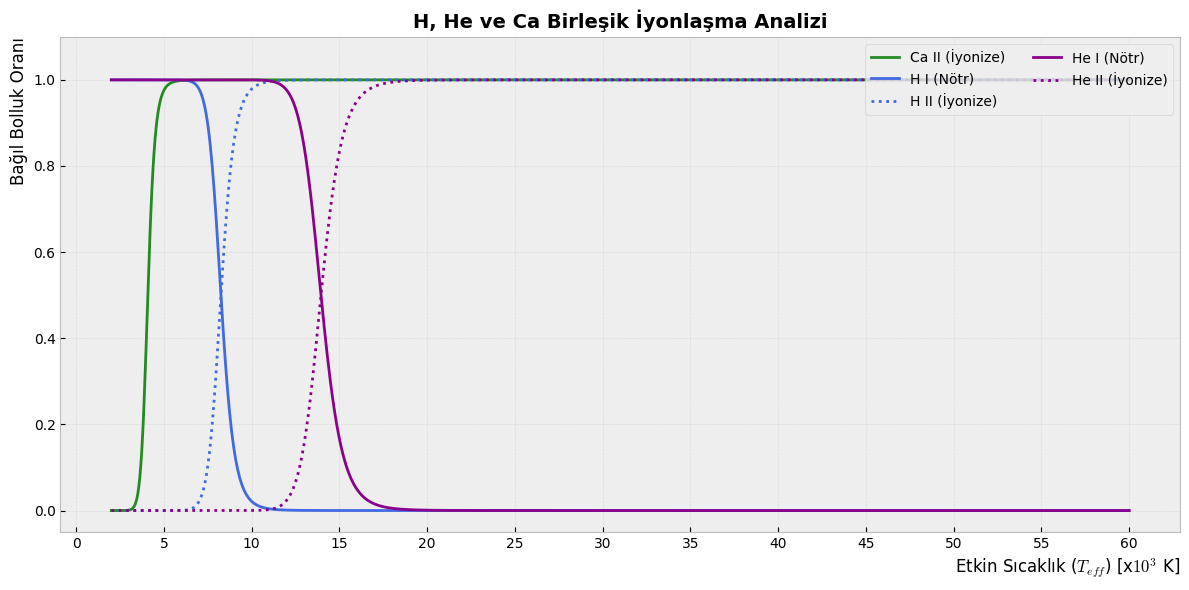

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Hesaplama Parametreleri
T_skalasi = np.linspace(2000, 60000, 1000)
Pe = 20.0
k_ev = 8.617e-5

# İyonlaşma Enerjileri (eV)
enerjiler = {'Ca': 6.11, 'H': 13.6, 'He': 24.58}

def saha_oranlari(T, E_ion):
    # Saha denklemi basitleştirilmiş logaritmik hesaplama
    log_R = 2.5 * np.log10(T) - (5040/T) * E_ion - np.log10(Pe) - 0.18
    R = 10**log_R
    return 1/(1+R), R/(1+R)

# Verileri hazırlayalım
ca_n0, ca_n1 = saha_oranlari(T_skalasi, enerjiler['Ca'])
h_n0, h_n1 = saha_oranlari(T_skalasi, enerjiler['H'])
he_n0, he_n1 = saha_oranlari(T_skalasi, enerjiler['He'])

# Grafik Çizimi - "ggplot" tarzı temiz bir tasarım
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-muted')

# Her element için farklı renk ve çizgi stili
plt.plot(T_skalasi/1000, ca_n1, label='Ca II (İyonize)', color='forestgreen', lw=2)
plt.plot(T_skalasi/1000, h_n0, label='H I (Nötr)', color='royalblue', lw=2)
plt.plot(T_skalasi/1000, h_n1, label='H II (İyonize)', color='royalblue', linestyle=':', lw=2)
plt.plot(T_skalasi/1000, he_n0, label='He I (Nötr)', color='darkmagenta', lw=2)
plt.plot(T_skalasi/1000, he_n1, label='He II (İyonize)', color='darkmagenta', linestyle=':', lw=2)

# Estetik Ayarlar
plt.title('H, He ve Ca Birleşik İyonlaşma Analizi', fontsize=14, fontweight='bold')
plt.xlabel('Etkin Sıcaklık ($T_{eff}$) [x$10^3$ K]', loc='right')
plt.ylabel('Bağıl Bolluk Oranı', loc='top')
plt.xticks(np.arange(0, 61, 5))
plt.ylim(-0.05, 1.1)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, frameon=True, loc='upper right')

plt.tight_layout()
plt.show()